# Part D – Handling Imbalanced Data

Tasks Covered:

13. Demonstrate the impact of class imbalance on model performance.
14. Apply:
   - Random Under-Sampling
   - Random Over-Sampling
   - SMOTE
   - ADASYN
15. Compare performance before and after balancing using:
   - Recall (Minority Class)
   - F1-Score
   - AUC-ROC


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv')

df.head()


,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [2]:
from sklearn.preprocessing import LabelEncoder

date_cols = [c for c in df.columns if 'date' in c.lower()]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    df[col+'_year'] = df[col].dt.year
    df[col+'_month'] = df[col].dt.month
    df[col+'_day'] = df[col].dt.day
    df.drop(columns=[col], inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

target = 'risk_status'

X = df.drop(target, axis=1)
y = df[target]


## Check Class Distribution

In [3]:
print(y.value_counts())
print("\nPercentage Distribution")
print(y.value_counts(normalize=True)*100)


risk_status
0    4043
1     557
Name: count, dtype: int64

Percentage Distribution
risk_status
0    87.891304
1    12.108696
Name: proportion, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)


## Baseline Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score,f1_score,roc_auc_score

baseline_model = LogisticRegression(max_iter=500, random_state=42)

baseline_model.fit(X_train,y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:,1]

baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)

print("Recall :", baseline_recall)
print("F1 Score :", baseline_f1)
print("AUC ROC :", baseline_auc)


Recall : 0.9369369369369369
F1 Score : 0.9497716894977168
AUC ROC : 0.9988975378344971


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Apply Sampling Techniques

In [6]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

sampling_methods = {
    'UnderSampling': RandomUnderSampler(random_state=42),
    'OverSampling': RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42)
}

results = []


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score,f1_score,roc_auc_score

for name, sampler in sampling_methods.items():

    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    model = LogisticRegression(max_iter=500, random_state=42)

    model.fit(X_resampled, y_resampled)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, recall, f1, auc])

    print("\n",name)
    print("Recall :", recall)
    print("F1 Score :", f1)
    print("AUC ROC :", auc)


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 UnderSampling
Recall : 0.9819819819819819
F1 Score : 0.9396551724137931
AUC ROC : 0.9988752658715576


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 OverSampling
Recall : 1.0
F1 Score : 0.940677966101695
AUC ROC : 0.9989866256862548


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 SMOTE
Recall : 0.990990990990991
F1 Score : 0.9482758620689655
AUC ROC : 0.99918707335271

 ADASYN
Recall : 1.0
F1 Score : 0.9288702928870293
AUC ROC : 0.9989643537233154


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Performance Comparison Table

In [8]:
results_df = pd.DataFrame(
    results,
    columns=['Technique','Recall','F1 Score','AUC ROC']
)

baseline_row = pd.DataFrame({
    'Technique':['Baseline'],
    'Recall':[baseline_recall],
    'F1 Score':[baseline_f1],
    'AUC ROC':[baseline_auc]
})

results_df = pd.concat([baseline_row, results_df], ignore_index=True)

results_df.sort_values('Recall', ascending=False)


,Technique,Recall,F1 Score,AUC ROC
2,OverSampling,1.000000,0.940678,0.998987
4,ADASYN,1.000000,0.928870,0.998964
3,SMOTE,0.990991,0.948276,0.999187
1,UnderSampling,0.981982,0.939655,0.998875
0,Baseline,0.936937,0.949772,0.998898


## Visualization

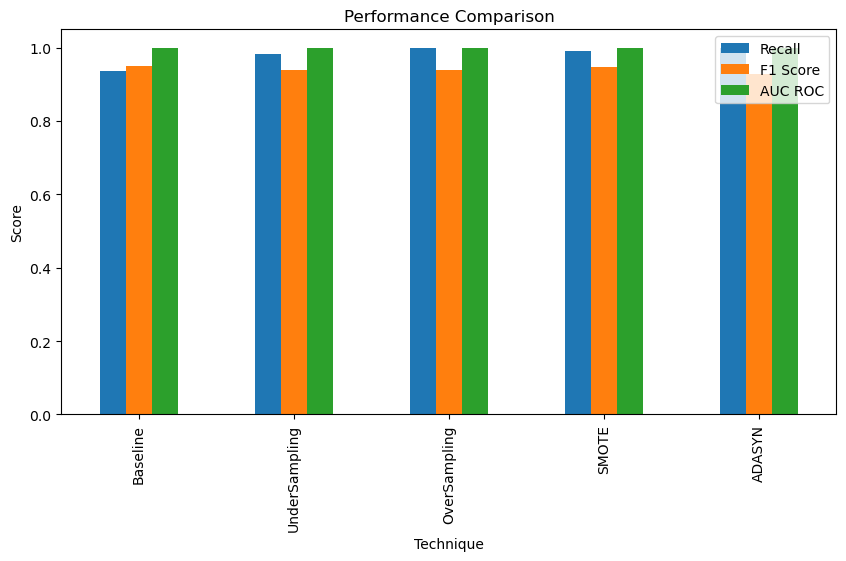

In [9]:
import matplotlib.pyplot as plt

results_df.set_index('Technique')[['Recall','F1 Score','AUC ROC']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Performance Comparison")
plt.ylabel("Score")
plt.show()


# Interpretation

### Under-Sampling
Reduces majority class observations to balance classes. Fast but may lose information.

### Over-Sampling
Duplicates minority samples. Improves minority detection but may overfit.

### SMOTE
Generates synthetic minority samples using nearest neighbors. Usually provides better generalization than simple over-sampling.

### ADASYN
Creates synthetic samples adaptively for difficult minority observations. Often improves recall for highly imbalanced datasets.

### Expected Result
For risk prediction, the best model is generally the one with:

- Highest Recall
- Strong F1 Score
- High AUC-ROC

because minimizing False Negatives is the primary business objective.
